# Importar librerías


In [42]:
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")

# Cargar los datos

## Función para leer datos de consumo

Esta función maneja correctamente las celdas fusionadas del Excel.

In [43]:
def leer_datos_consumo(archivo, hoja):
    """
    Lee los datos de consumo de una hoja específica del archivo Excel.

    Parámetros:
    -----------
    archivo : str
        Ruta al archivo Excel
    hoja : str
        Nombre de la hoja a leer (METRO_ENV, METRO_SAND o METRO_ZAMO)

    Retorna:
    --------
    DataFrame con las siguientes columnas:
    - Fecha: fecha en formato datetime
    - H1, H2, ..., H24: consumo por hora en kWh
    - Total: suma de las 24 horas
    """

    # Cargar el workbook con openpyxl para manejar celdas fusionadas
    wb = openpyxl.load_workbook(archivo, data_only=True)
    ws = wb[hoja]

    # La tabla comienza en la fila 16 (encabezados) y 17 (datos)
    fila_inicio_datos = 17

    # Leer datos fila por fila
    datos = []

    for fila in range(fila_inicio_datos, ws.max_row + 1):
        # La fecha está en la columna B (columna 2), pero fusionada en B:D
        fecha = ws.cell(row=fila, column=2).value

        # Si no hay fecha, hemos llegado al final de los datos
        if fecha is None or not isinstance(fecha, str):
            break

        # Leer las 24 horas de consumo
        fila_datos = {'Fecha': fecha}

        # Las horas están en columnas que tienen fusiones:
        # H1: columna E (5)
        # H2: columna G (7)
        # H3: columna H (8)
        # H4: columna I (9)
        # Y así sucesivamente...

        # Mapeo de las columnas de horas (basado en la estructura observada)
        columnas_horas = [
            5,   # H1 (E)
            7,   # H2 (G)
            8,   # H3 (H)
            9,   # H4 (I)
            12,  # H5 (L)
            14,  # H6 (N)
            16,  # H7 (P)
            21,  # H8 (U)
            22,  # H9 (V)
            23,  # H10 (W)
            24,  # H11 (X)
            25,  # H12 (Y)
            26,  # H13 (Z)
            27,  # H14 (AA)
            28,  # H15 (AB)
            29,  # H16 (AC)
            30,  # H17 (AD)
            31,  # H18 (AE)
            32,  # H19 (AF)
            33,  # H20 (AG)
            34,  # H21 (AH)
            35,  # H22 (AI)
            36,  # H23 (AJ)
            37,  # H24 (AK)
        ]

        # Leer cada hora
        for i, col in enumerate(columnas_horas, 1):
            valor = ws.cell(row=fila, column=col).value
            fila_datos[f'H{i}'] = valor if valor is not None else 0

        # La columna total está en AL (38)
        total = ws.cell(row=fila, column=38).value
        fila_datos['Total'] = total if total is not None else 0

        datos.append(fila_datos)

    # Crear DataFrame
    df = pd.DataFrame(datos)

    # Convertir fecha a datetime
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

    # Asegurar que las columnas de consumo sean numéricas
    columnas_numericas = [f'H{i}' for i in range(1, 25)] + ['Total']
    for col in columnas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    wb.close()

    return df

## Leer los datos

In [44]:
archivo1 = 'Consumos 2018-2020.xlsx'
archivo2 = 'VipRptConsumosDiariosHorariosPpal2023-2024.xlsx'

# Leer las tres hojas
df_env_2018_2020 = leer_datos_consumo(archivo1, 'METRO_ENV')
df_sand_2018_2020 = leer_datos_consumo(archivo1, 'METRO_SAND')
df_zamo_2018_2020 = leer_datos_consumo(archivo1, 'METRO_ZAMO')

df_env_2023_2024 = leer_datos_consumo(archivo2, 'METRO_ENV')
df_sand_2023_2024 = leer_datos_consumo(archivo2, 'METRO_SAND')
df_zamo_2023_2024 = leer_datos_consumo(archivo2, 'METRO_ZAMO')



Unir las bases de datos y ordenar por fecha

In [21]:
#Unir
df_env = pd.concat([df_env_2018_2020, df_env_2023_2024],ignore_index=True
)

df_sand = pd.concat([df_sand_2018_2020, df_sand_2023_2024],ignore_index=True
)

df_zamo = pd.concat([df_zamo_2018_2020, df_zamo_2023_2024],ignore_index=True
)

#Ordenar
df_env = df_env.sort_values("Fecha").reset_index(drop=True)
df_sand = df_sand.sort_values("Fecha").reset_index(drop=True)
df_zamo = df_zamo.sort_values("Fecha").reset_index(drop=True)

In [26]:
df_env["Fecha"].dt.year.value_counts().sort_index()

,count
Fecha,
2018,365
2019,365
2020,366
2023,365
2024,366


# Entendimiento de los datos

In [27]:
# Ver las primeras filas de METRO_ENV
print("\n=== METRO_ENV - Primeras 5 filas ===")
print(df_env.head())

print("\n=== Información del DataFrame ===")
print(df_env.info())

print("\n=== Estadísticas descriptivas ===")
print(df_env[['H1', 'H2', 'H3', 'Total']].describe())


=== METRO_ENV - Primeras 5 filas ===
       Fecha        H1        H2        H3        H4         H5         H6  \
0 2018-01-01  164.9999  164.9999  161.3332  164.9999   183.3336   718.6671   
1 2018-01-02  157.6667  157.6667  150.3337  249.3332  1569.3336  4205.6678   
2 2018-01-03  198.0002  194.3337  194.3337  234.6669  1723.3338  4414.6678   
3 2018-01-04  205.3332  201.6667  198.0002  245.6667  1694.0006  4216.6679   
4 2018-01-05  216.3333  212.6666  208.9999  293.3334  1595.0006  4257.0009   

          H7         H8         H9  ...        H16        H17        H18  \
0  2126.6671  1903.0000  2005.6670  ...  1987.3335  2053.3338  1936.0004   
1  4374.3343  4484.3346  3534.6676  ...  3633.6676  4675.0011  5093.0014   
2  4836.3346  4649.3346  3732.6677  ...  3809.6676  4517.3343  4788.6675   
3  4455.0008  4165.3343  3927.0008  ...  3443.0011  4880.3346  4928.0013   
4  4766.6681  4455.0013  3600.6677  ...  3820.6678  4554.0011  5115.0011   

         H19        H20        H21  

## Confirmar consistencia

In [30]:
# Rango de fechas
print("Rango de fechas por estación:")
print(f"METRO_ENV: {df_env['Fecha'].min()} a {df_env['Fecha'].max()}")
print(f"METRO_SAND: {df_sand['Fecha'].min()} a {df_sand['Fecha'].max()}")
print(f"METRO_ZAMO: {df_zamo['Fecha'].min()} a {df_zamo['Fecha'].max()}")

# Verificar si el total coincide con la suma de las horas
df_env['Suma_Calculada'] = df_env[[f'H{i}' for i in range(1, 25)]].sum(axis=1)
df_env['Diferencia'] = abs(df_env['Total'] - df_env['Suma_Calculada'])
print()
print(f"Máxima diferencia entre Total y suma calculada: {df_env['Diferencia'].max():.2f} kWh")
print(f"Registros con diferencia > 1 kWh: {(df_env['Diferencia'] > 1).sum()}")

Rango de fechas por estación:
METRO_ENV: 2018-01-01 00:00:00 a 2024-12-31 00:00:00
METRO_SAND: 2018-01-01 00:00:00 a 2024-12-31 00:00:00
METRO_ZAMO: 2018-01-01 00:00:00 a 2024-12-31 00:00:00

Máxima diferencia entre Total y suma calculada: 0.00 kWh
Registros con diferencia > 1 kWh: 0


## Visualizaciones

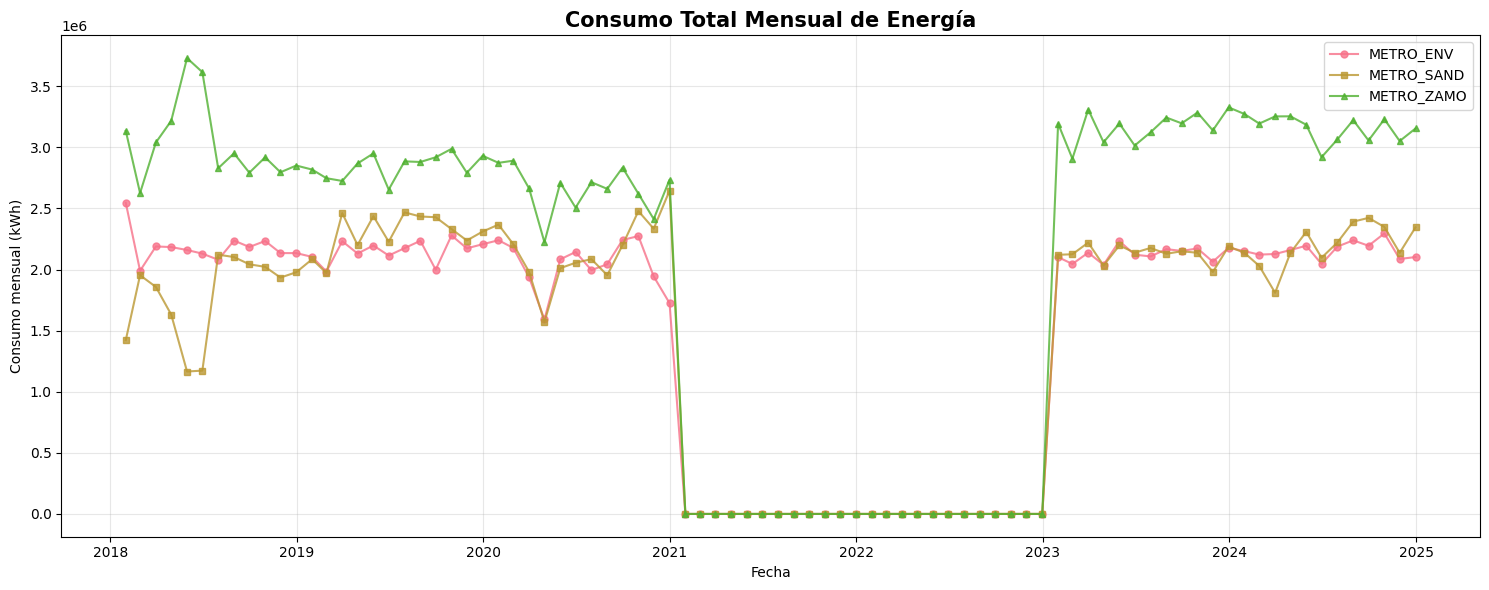

In [39]:

# Pasar de consumo diario a semanal
env_mensual = (
    df_env
    .set_index('Fecha')['Total']
    .resample('ME')
    .sum()
)

sand_mensual = (
    df_sand
    .set_index('Fecha')['Total']
    .resample('ME')
    .sum()
)

zamo_mensual = (
    df_zamo
    .set_index('Fecha')['Total']
    .resample('ME')
    .sum()
)


plt.figure(figsize=(15, 6))

plt.plot(
    env_mensual.index, env_mensual.values,
    label='METRO_ENV',
    marker='o',
    markersize=5,
    alpha=0.8
)

plt.plot(
    sand_mensual.index, sand_mensual.values,
    label='METRO_SAND',
    marker='s',
    markersize=5,
    alpha=0.8
)

plt.plot(
    zamo_mensual.index, zamo_mensual.values,
    label='METRO_ZAMO',
    marker='^',
    markersize=5,
    alpha=0.8
)

plt.title('Consumo Total Mensual de Energía', fontsize=15, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Consumo mensual (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



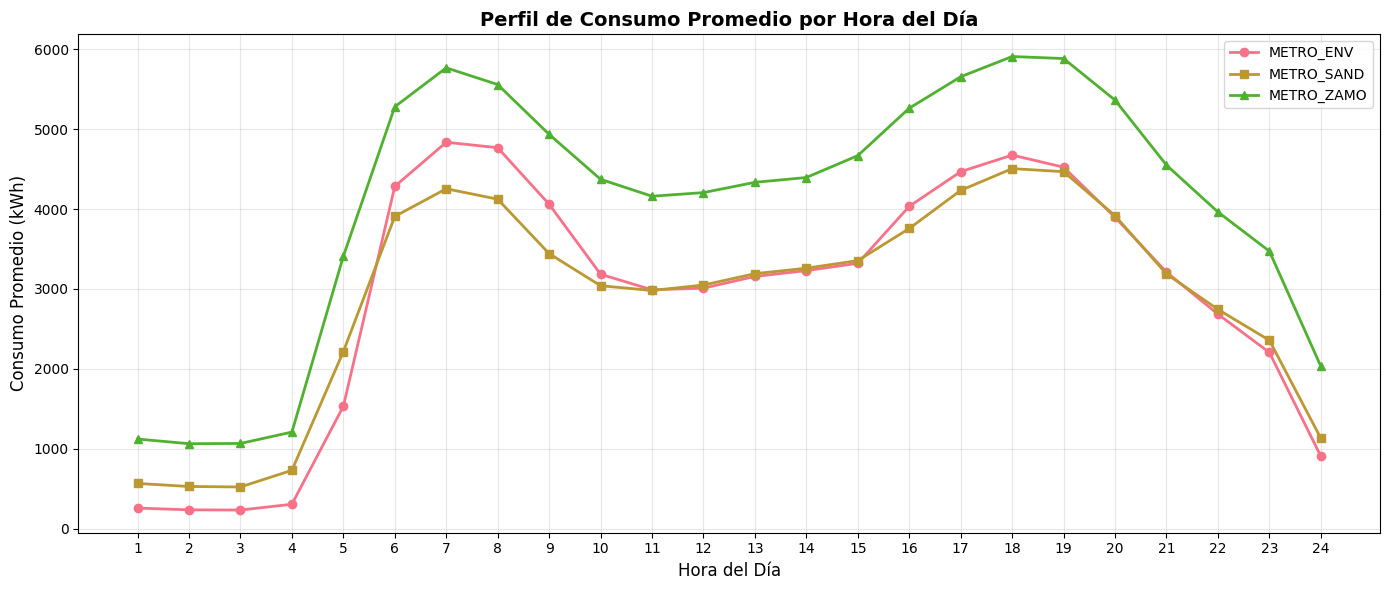

In [40]:
# Perfil de consumo por hora (promedio)
columnas_horas = [f'H{i}' for i in range(1, 25)]
consumo_promedio_hora_env = df_env[columnas_horas].mean()
consumo_promedio_hora_sand = df_sand[columnas_horas].mean()
consumo_promedio_hora_zamo = df_zamo[columnas_horas].mean()

fig, ax = plt.subplots(figsize=(14, 6))
horas = range(1, 25)

ax.plot(horas, consumo_promedio_hora_env, marker='o', label='METRO_ENV', linewidth=2)
ax.plot(horas, consumo_promedio_hora_sand, marker='s', label='METRO_SAND', linewidth=2)
ax.plot(horas, consumo_promedio_hora_zamo, marker='^', label='METRO_ZAMO', linewidth=2)

ax.set_title('Perfil de Consumo Promedio por Hora del Día', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del Día', fontsize=12)
ax.set_ylabel('Consumo Promedio (kWh)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 25))

plt.tight_layout()
plt.show()

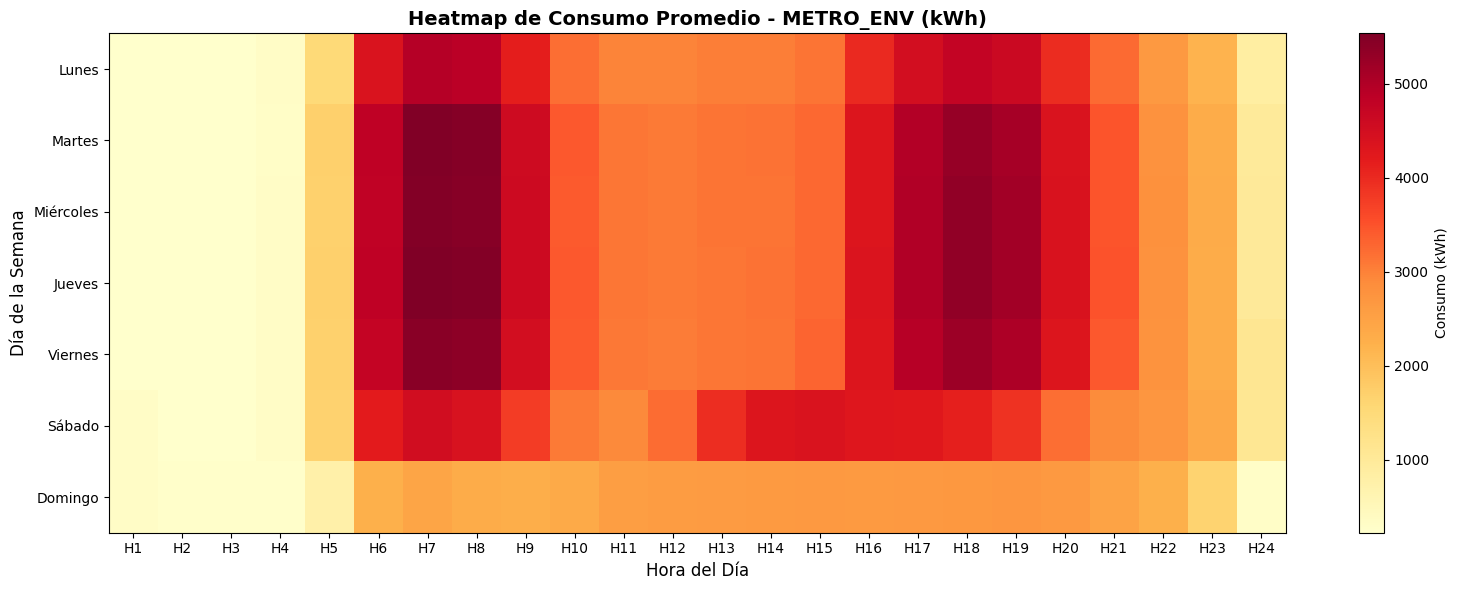

In [41]:
# Heatmap de consumo por hora y día de la semana (METRO_ENV como ejemplo)
df_env['DiaSemana'] = df_env['Fecha'].dt.day_name()
df_env['NumeroDiaSemana'] = df_env['Fecha'].dt.dayofweek

# Crear matriz para el heatmap
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_espanol = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

matriz_consumo = []
for dia in dias_orden:
    datos_dia = df_env[df_env['DiaSemana'] == dia][columnas_horas].mean()
    matriz_consumo.append(datos_dia.values)

matriz_consumo = np.array(matriz_consumo)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(matriz_consumo, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(24))
ax.set_xticklabels([f'H{i}' for i in range(1, 25)])
ax.set_yticks(range(7))
ax.set_yticklabels(dias_espanol)

ax.set_title('Heatmap de Consumo Promedio - METRO_ENV (kWh)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del Día', fontsize=12)
ax.set_ylabel('Día de la Semana', fontsize=12)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Consumo (kWh)', fontsize=10)

plt.tight_layout()
plt.show()